# Jigsaw Puzzle Image Segmentation
This notebook processes a high-resolution photo with a non-uniform background to segment individual jigsaw puzzle pieces.

## 1. Environment Setup & Settings
Here we define variables like `block_size`, `constant_c`, and `min_area` to tune the algorithm.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- SETTINGS ---
# Variables for tuning the algorithm

# Bilateral Filter parameters
d = 9 # Diameter of each pixel neighborhood
sigmaColor = 75 # Filter sigma in the color space
sigmaSpace = 75 # Filter sigma in the coordinate space

# Adaptive Gaussian Thresholding parameters
# block_size specifies the size of a pixel neighborhood that is used to calculate a threshold value for the pixel. Must be odd.
block_size = 51 
# constant_c is the constant subtracted from the mean or weighted mean. Normally positive.
constant_c = 10 

# Contour extraction parameters
min_area = 1000 # Filter out small artifacts based on area (in pixels)

# Input/Output paths
image_path = '../data/pieces.jpg'
output_dir = '../pieces_output'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Helper function to plot images side-by-side
def plot_side_by_side(img1, title1, img2, title2, cmap1=None, cmap2=None):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(img1, cmap=cmap1)
    axes[0].set_title(title1)
    axes[0].axis('off')
    
    axes[1].imshow(img2, cmap=cmap2)
    axes[1].set_title(title2)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

## 2. Original Image
Load the image using OpenCV and convert it to RGB format for visualization via matplotlib.

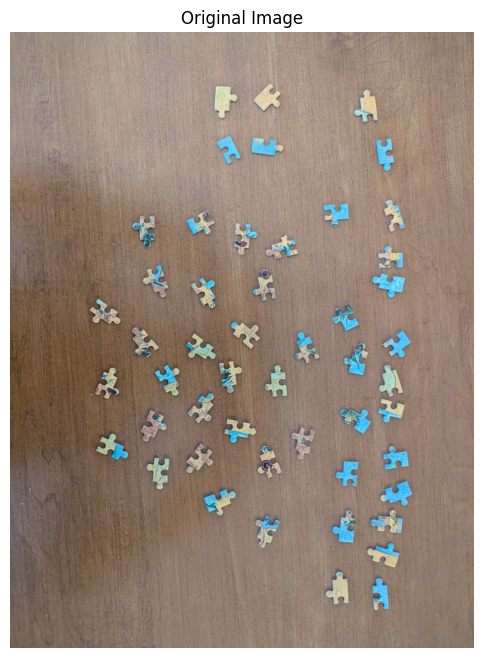

In [2]:
original_img = cv2.imread(image_path)
if original_img is None:
    print(f"Error: Could not load image from {image_path}. Please check the path.")
else:
    # Convert from BGR (OpenCV default) to RGB (Matplotlib default)
    original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(original_rgb)
    plt.title('Original Image')
    plt.axis('off')
    plt.show()

## 3. Grayscale & Color Space
We examine different color spaces. The LAB color space is highly effective for segmentation as it isolates Lightness (L) from color data (A and B).

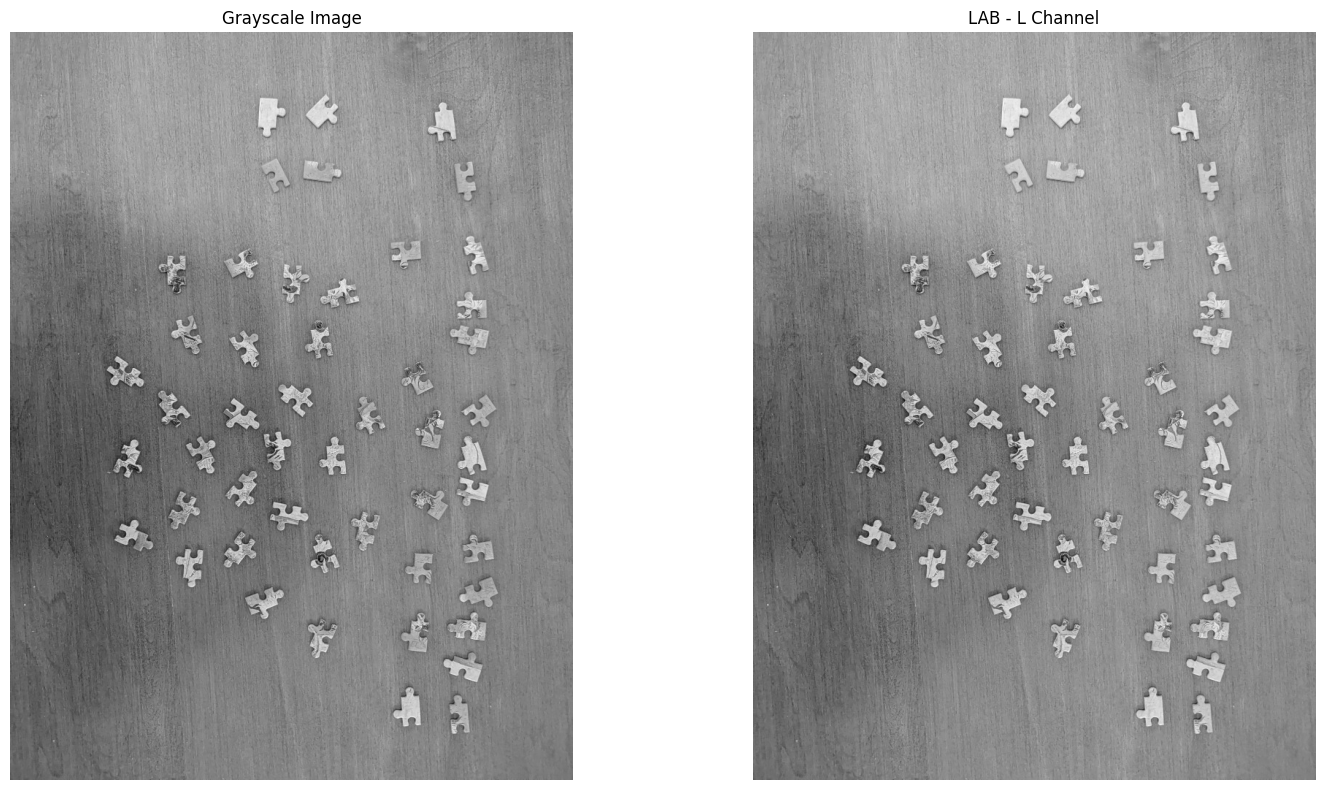

In [3]:
# Convert to LAB color space
lab_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2LAB)
l_channel, a_channel, b_channel = cv2.split(lab_img)

# Standard Grayscale
gray_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)

# Displaying Grayscale vs Lightness channel
# Choosing the L channel is often better since it emphasizes brightness variations differently.
plot_side_by_side(gray_img, 'Grayscale Image', l_channel, 'LAB - L Channel', cmap1='gray', cmap2='gray')

## 4. Blurred (Noise Reduction)
Use a Bilateral Filter to remove background texture (like wood grain) while preserving the sharp edges of the puzzle pieces. This is crucial before thresholding.

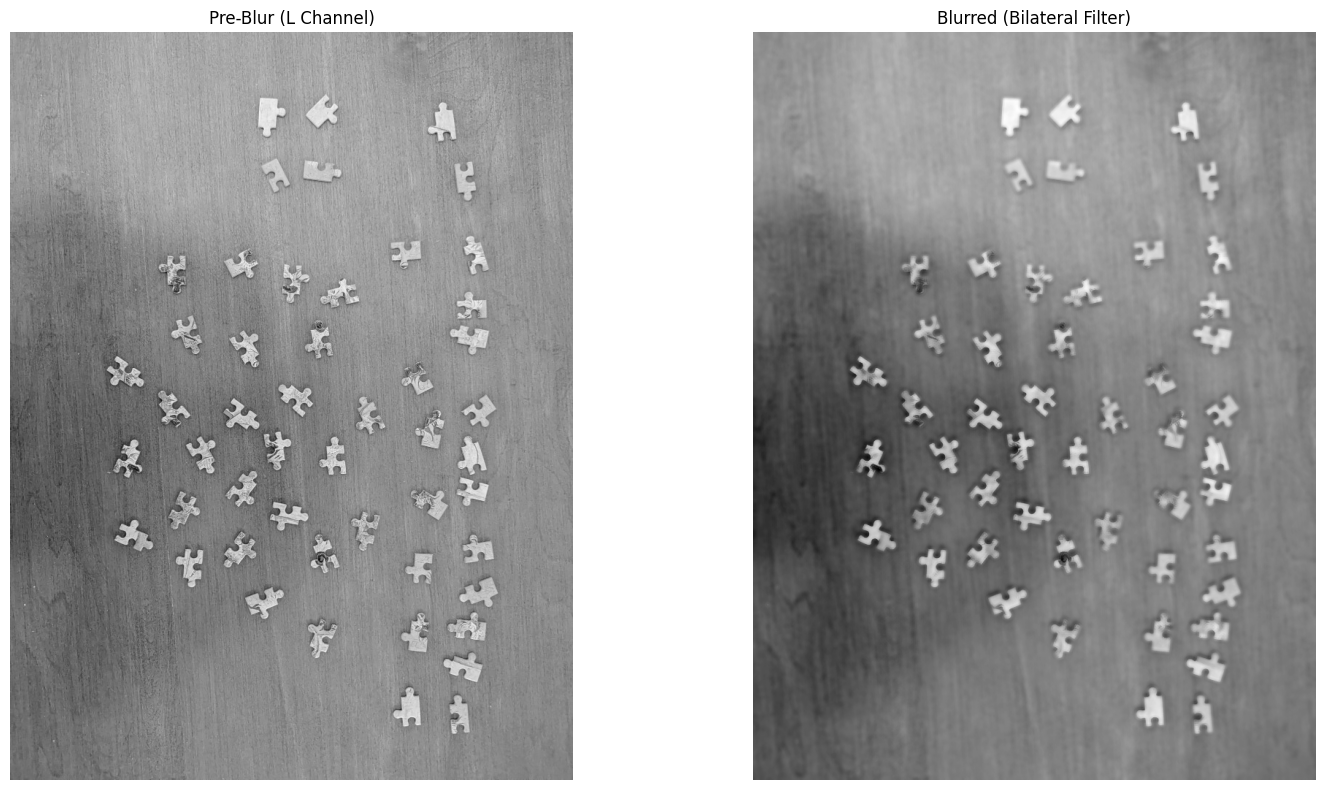

In [4]:
# We apply the bilateral filter to the L channel from LAB, as it usually represents lighting best.
blurred_img = cv2.bilateralFilter(l_channel, d, sigmaColor, sigmaSpace)

plot_side_by_side(l_channel, 'Pre-Blur (L Channel)', blurred_img, 'Blurred (Bilateral Filter)', cmap1='gray', cmap2='gray')

## 5. Thresholded (Adaptive Gaussian Thresholding)

### Math Behind Adaptive Gaussian Thresholding:
Unlike global thresholding (which uses a single threshold value for the entire image), adaptive thresholding calculates a custom threshold for *each pixel* based on its surrounding neighborhood.

For Adaptive Gaussian Thresholding, the threshold value $T(x,y)$ for a pixel at $(x,y)$ is calculated as:

1. **Neighborhood Window**: A window of size `block_size` $\times$ `block_size` is centered around $(x,y)$.
2. **Gaussian Weighting**: The algorithm computes the weighted sum (cross-correlation) of the pixels in this window with a 2D Gaussian kernel. This emphasizes pixels closer to the center.
3. **Mean Calculation**: This weighted sum returns the *Gaussian-weighted mean* of the neighborhood, yielding expected local brightness $\mu(x,y)$.
4. **Constant Subtraction**: The final threshold is determined by subtracting `constant_c` from this mean: $T(x,y) = \mu(x,y) - C$.
5. **Binarization**: 
   - If the pixel value $P(x,y) > T(x,y)$, it's assigned the max value (e.g., 255/White).
   - Otherwise, it's set to 0 (Black).

Since puzzle pieces often cast shadows and ambient lighting is non-uniform, this algorithm ensures robust adaptation to varying brightness regions.

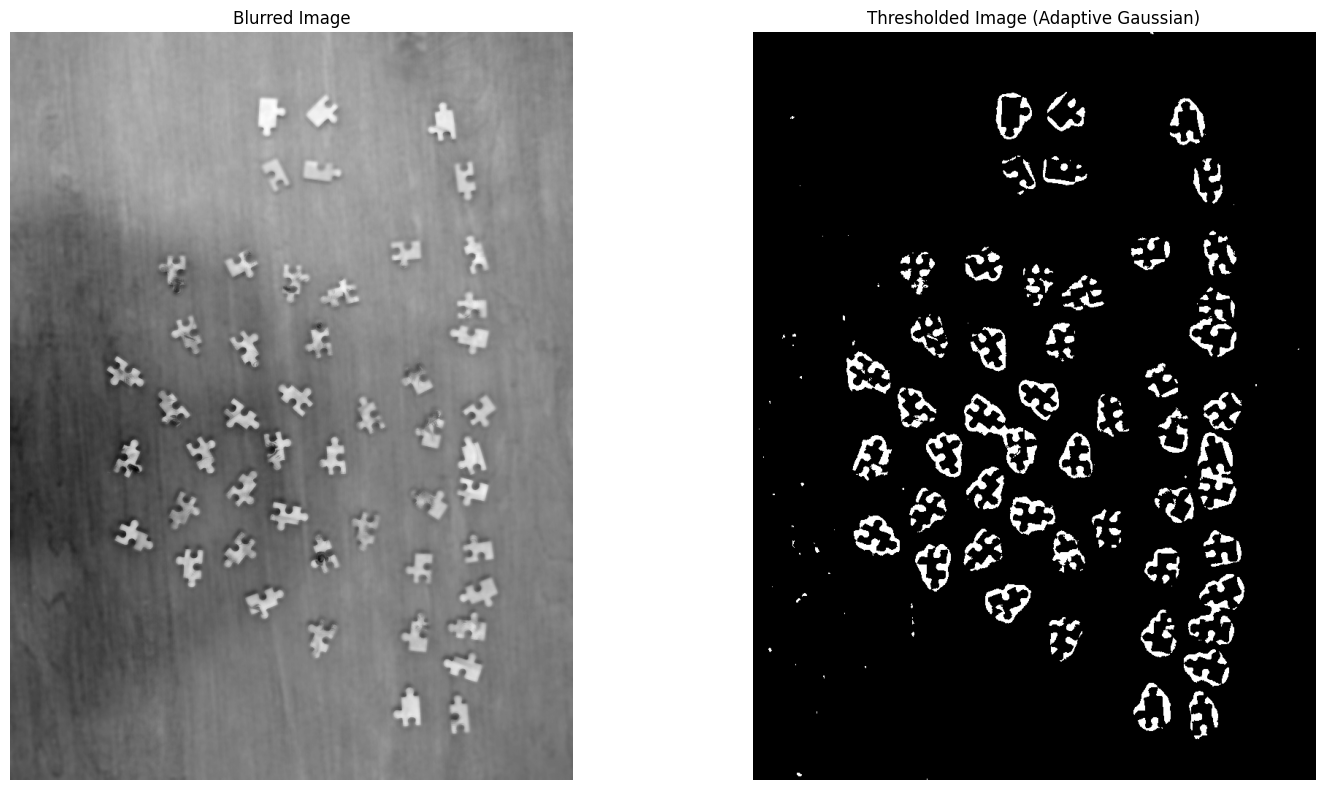

In [5]:
# We apply the adaptive threshold.
# Note: Since we want pieces to be white (255) and background dark (0), 
# the chosen flag `cv2.THRESH_BINARY_INV` or `cv2.THRESH_BINARY` might need testing based on table color.
thresh_img = cv2.adaptiveThreshold(
    blurred_img, 
    255, 
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY_INV, 
    block_size, 
    constant_c
)

plot_side_by_side(blurred_img, 'Blurred Image', thresh_img, 'Thresholded Image (Adaptive Gaussian)', cmap1='gray', cmap2='gray')

## 6. Masked (Refinement / Morphological Operations)
Use Morphological Operations (Opening/Closing) to fill internal holes in pieces and remove small background noise.

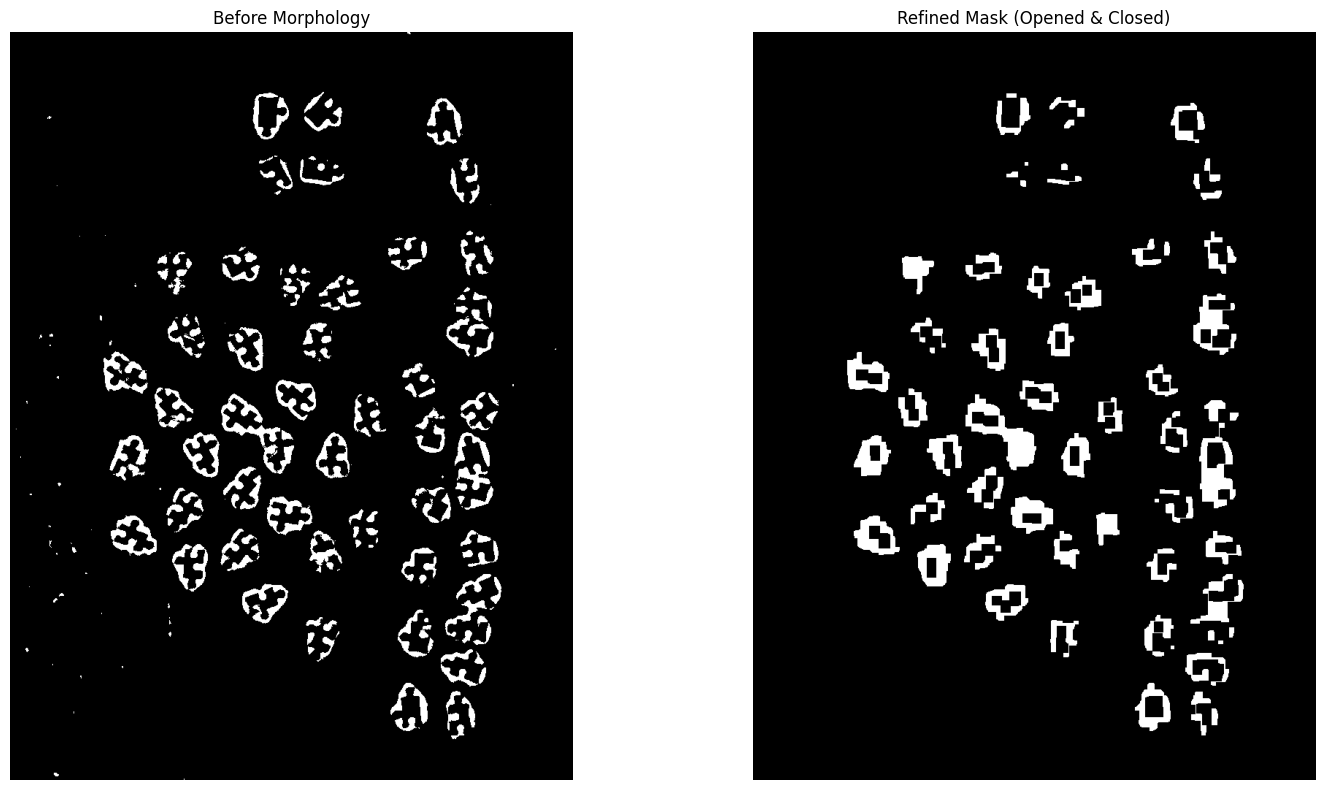

In [6]:
kernel = np.ones((5,5), np.uint8)

# 1. Morphological Opening (Erosion followed by Dilation): Removes small bright noise in the background
refined_mask = cv2.morphologyEx(thresh_img, cv2.MORPH_OPEN, kernel, iterations=1)

# 2. Morphological Closing (Dilation followed by Erosion): Closes small dark holes inside the pieces
refined_mask = cv2.morphologyEx(refined_mask, cv2.MORPH_CLOSE, kernel, iterations=3)

plot_side_by_side(thresh_img, 'Before Morphology', refined_mask, 'Refined Mask (Opened & Closed)', cmap1='gray', cmap2='gray')

## 7. Final Contours & Extraction
Find contours using `RETR_EXTERNAL` on the refined mask. We filter out small artifacts based on `min_area`.

Found 19 pieces after filtering.


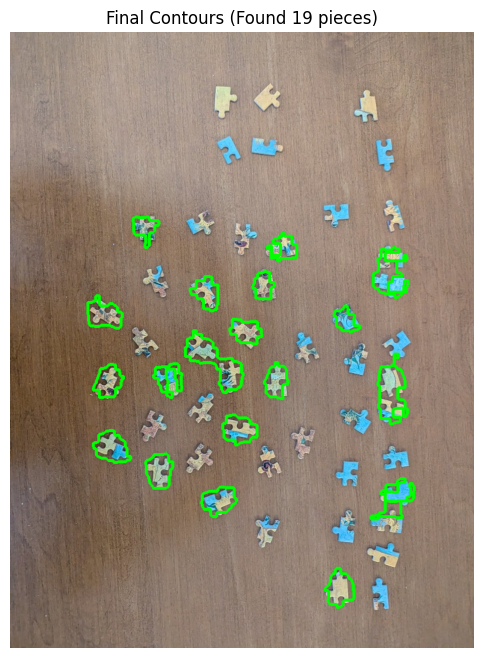

In [7]:
# Find contours on the refined mask
contours, hierarchy = cv2.findContours(refined_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

filtered_contours = []
contours_img = original_rgb.copy()

# Filter by min_area and draw
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > min_area:
        filtered_contours.append(cnt)
        cv2.drawContours(contours_img, [cnt], -1, (0, 255, 0), 3)

print(f"Found {len(filtered_contours)} pieces after filtering.")

plt.figure(figsize=(10, 8))
plt.imshow(contours_img)
plt.title(f'Final Contours (Found {len(filtered_contours)} pieces)')
plt.axis('off')
plt.show()

## 8. Exporting Transparent PNGs
For each valid piece, generate a Transparent PNG (4-channel RGBA) where the background is removed, and the piece is centered natively around its extracted dimensions.

In [8]:
for i, cnt in enumerate(filtered_contours):
    # Get bounding box for the contour
    x, y, w, h = cv2.boundingRect(cnt)
    
    # Create an empty mask for the entire original image size
    piece_mask = np.zeros(original_img.shape[:2], dtype=np.uint8)
    
    # Draw the specific contour on the mask filled with white (255)
    cv2.drawContours(piece_mask, [cnt], -1, 255, thickness=cv2.FILLED)
    
    # Crop original image and the piece mask to the bounding box
    cropped_img = original_img[y:y+h, x:x+w]
    cropped_mask = piece_mask[y:y+h, x:x+w]
    
    # Create an RGBA image (4 channels)
    # Start by splitting the cropped BGR image
    b, g, r = cv2.split(cropped_img)
    
    # Merge channels adding the cropped mask as the Alpha channel
    rgba_piece = cv2.merge([b, g, r, cropped_mask])
    
    output_filename = os.path.join(output_dir, f'piece_{i+1:03d}.png')
    
    # OpenCV imwrite handles RGBA transparency natively when saved as PNG
    cv2.imwrite(output_filename, rgba_piece)

print(f"Successfully saved {len(filtered_contours)} transparent pieces to {output_dir}")


Successfully saved 19 transparent pieces to ../pieces_output
